# Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
import tensorflow as tf
from tensorflow.keras.utils import to_categorical

# EDA (Exploratory Data Analysis)

****Before Data Augmentation****

In [2]:
base_dir='input'
class_labels=os.listdir(base_dir)
class_labels.sort()
print(class_labels)

['Clams', 'Dolphin', 'Jelly Fish', 'Lobster', 'Nudibranchs']


In [3]:
chart_data = []
chart_labels = []

for label in class_labels:
    chart_labels.append(label)
    path = os.path.join(base_dir,label)
    size = len(os.listdir(path))
    chart_data.append(size)
    print(f'Target name: {label:<15} | number of samples in data: {size}')

Target name: Clams           | number of samples in data: 501
Target name: Dolphin         | number of samples in data: 501
Target name: Jelly Fish      | number of samples in data: 501
Target name: Lobster         | number of samples in data: 501
Target name: Nudibranchs     | number of samples in data: 501


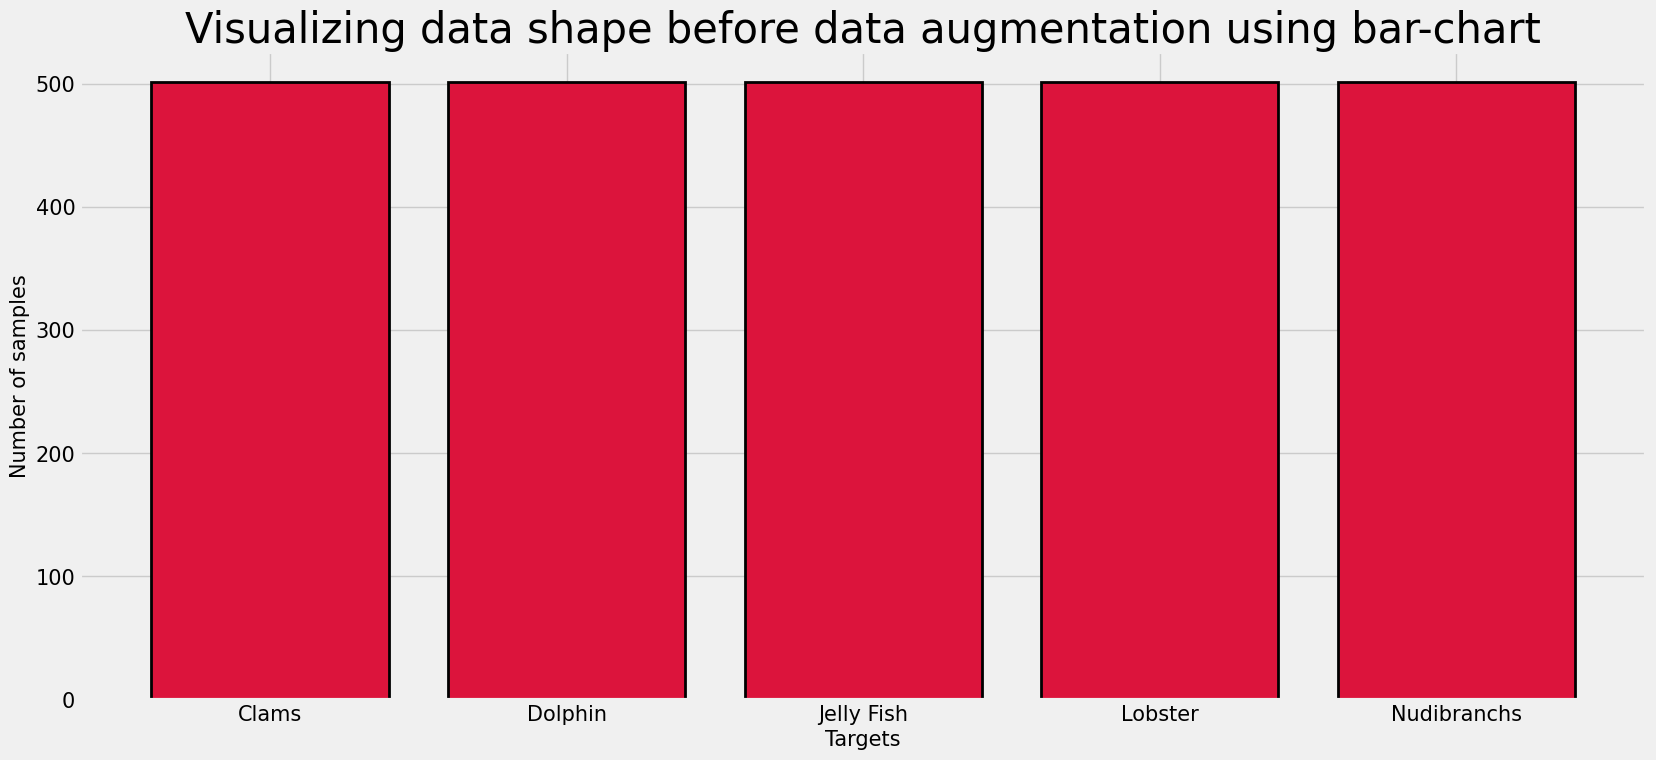

In [4]:
with plt.style.context(style="fivethirtyeight"):
    plt.figure(figsize=(18,8))
    plt.bar(x=chart_labels,
           height=chart_data,
           edgecolor='black',
           linewidth=2,
            color='crimson')
    plt.title(label='Visualizing data shape before data augmentation using bar-chart', fontsize=30)
    plt.xlabel(xlabel='Targets', fontsize=15)
    plt.ylabel(ylabel='Number of samples', fontsize=15)
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    plt.show()

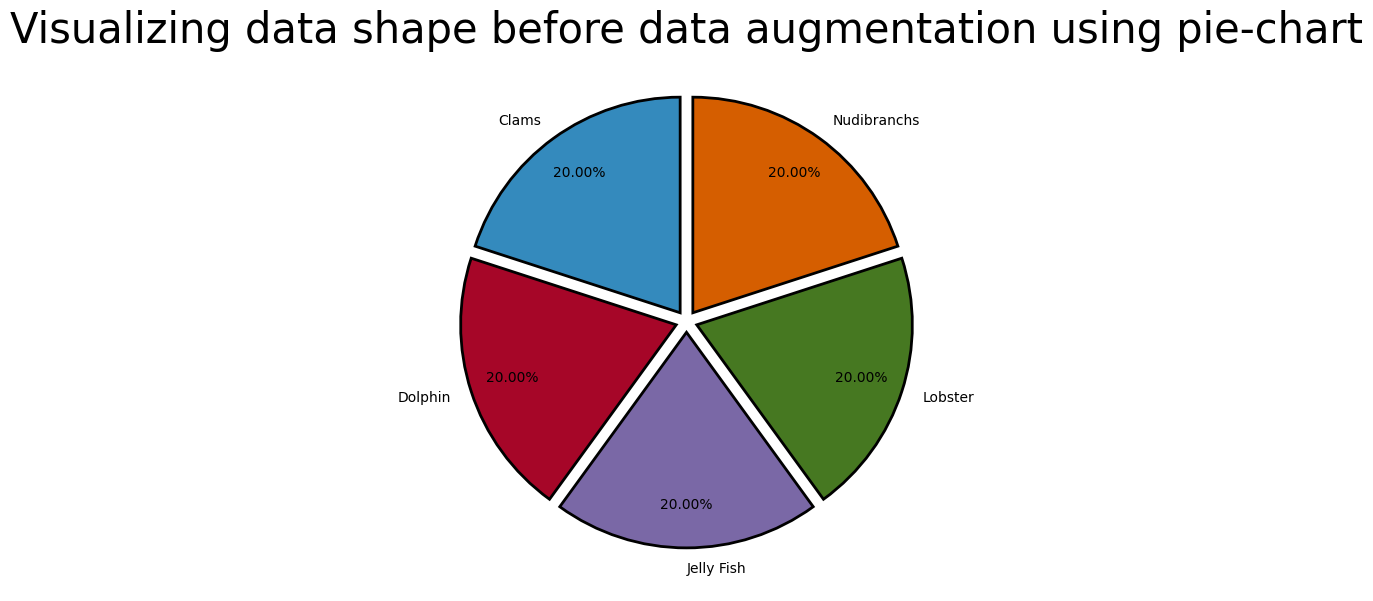

In [5]:
with plt.style.context(style='bmh'):
    plt.figure(figsize=(7,7))
    plt.pie(labels=chart_labels,
            explode=[0.05]*len(class_labels),
            x=chart_data,
            autopct='%.2f%%',
            startangle=90,
            pctdistance=0.80, wedgeprops={'linewidth':2,'edgecolor':'black'})
    plt.title(label='Visualizing data shape before data augmentation using pie-chart', fontsize=30)
    plt.show()

****After Data Augmentation****

In [6]:
base_dir='input'
class_labels=os.listdir(base_dir)
class_labels.sort()
print(class_labels)

['Clams', 'Dolphin', 'Jelly Fish', 'Lobster', 'Nudibranchs']


In [7]:
chart_data = []
chart_labels = []

for label in class_labels:
    chart_labels.append(label)
    path = os.path.join(base_dir,label)
    size = len(os.listdir(path))
    chart_data.append(size)
    print(f'Target name: {label:<15} | number of samples in data: {size}')

Target name: Clams           | number of samples in data: 501
Target name: Dolphin         | number of samples in data: 501
Target name: Jelly Fish      | number of samples in data: 501
Target name: Lobster         | number of samples in data: 501
Target name: Nudibranchs     | number of samples in data: 501


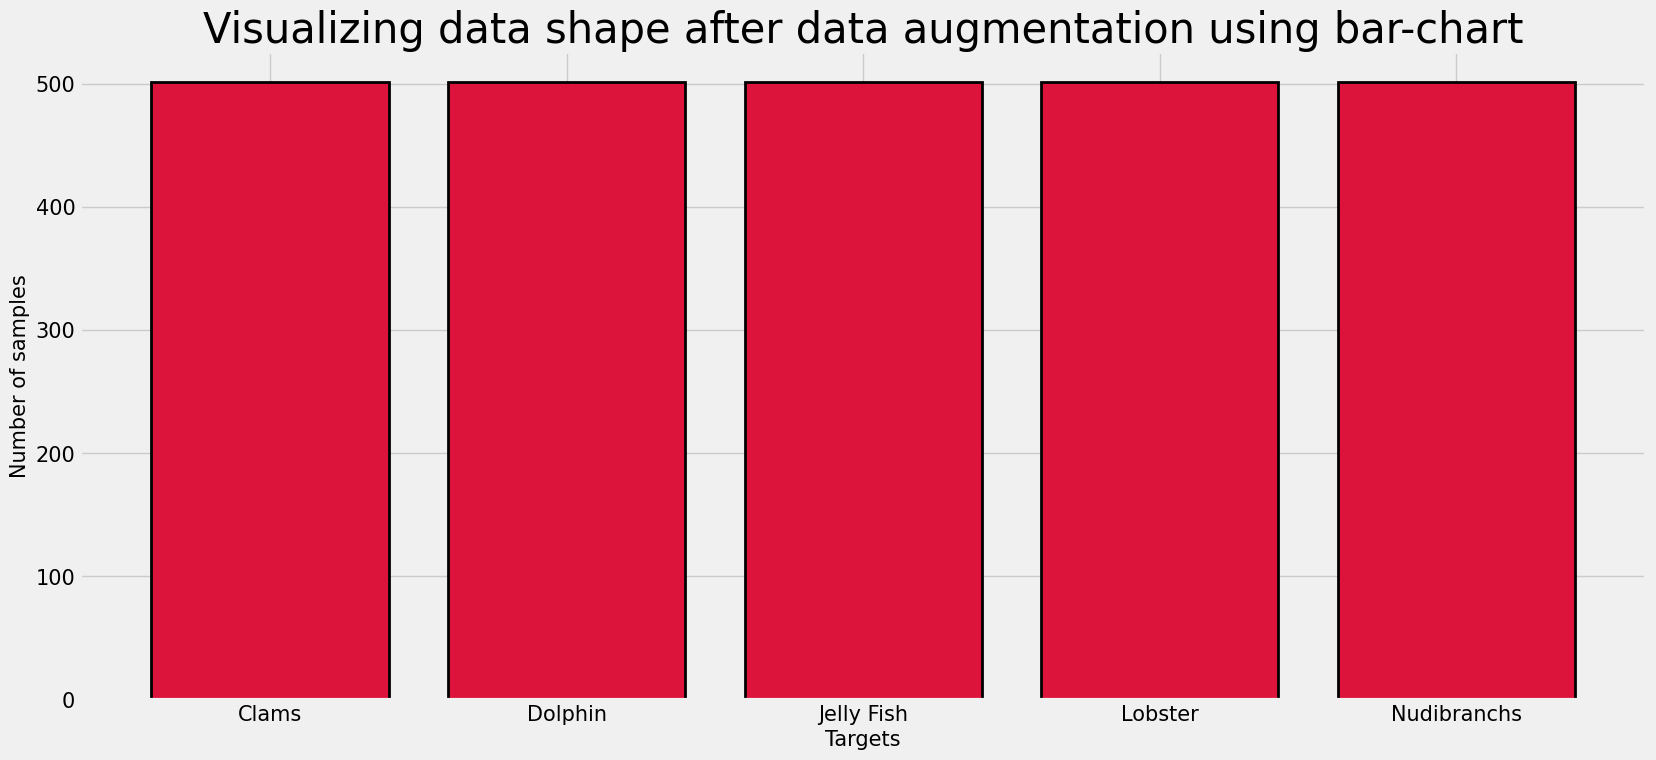

In [8]:
with plt.style.context(style="fivethirtyeight"):
    plt.figure(figsize=(18,8))
    plt.bar(x=chart_labels,
           height=chart_data,
           edgecolor='black',
           linewidth=2,
            color='crimson')
    plt.title(label='Visualizing data shape after data augmentation using bar-chart', fontsize=30)
    plt.xlabel(xlabel='Targets', fontsize=15)
    plt.ylabel(ylabel='Number of samples', fontsize=15)
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    plt.show()

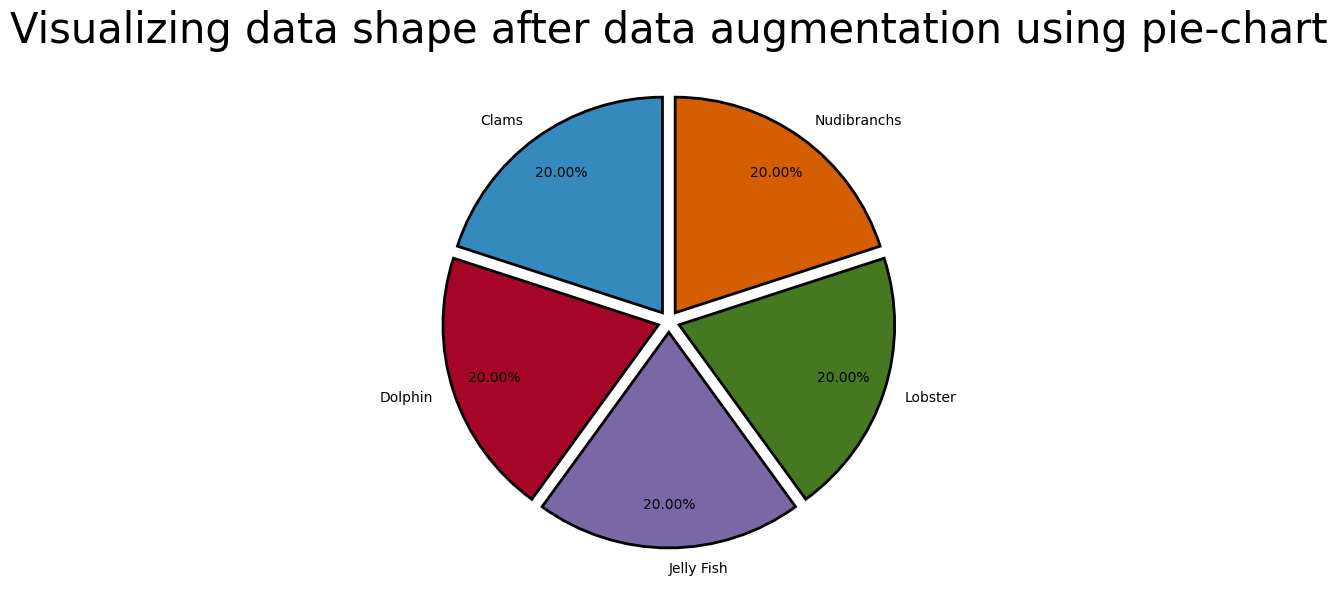

In [9]:
with plt.style.context(style='bmh'):
    plt.figure(figsize=(7,7))
    plt.pie(labels=chart_labels,
            explode=[0.05]*len(class_labels),
            x=chart_data,
            autopct='%.2f%%',
            startangle=90,
            pctdistance=0.80,
            wedgeprops={'linewidth':2,'edgecolor':'black'})
    plt.title(label='Visualizing data shape after data augmentation using pie-chart', fontsize=30)
    plt.show()

In [10]:
X = []
y = []
class_name=0
for label in class_labels:
    path=os.path.join(base_dir,label)
    files=os.listdir(path)
    print(f"Loading images from {label} target...")
    for sample in tqdm(files):
        filepath=os.path.join(path,sample)
        try:
            image=cv2.imread(filepath)
            image=cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
            image=cv2.resize(image,(128,128))
            image=np.array(image)
            image=image/255.0
            X.append(image)
            y.append(class_name)
        except:
            continue
    class_name+=1

Loading images from Clams target...


100%|███████████████████████████████████████████████████████████████████████████████| 501/501 [00:03<00:00, 132.00it/s]


Loading images from Dolphin target...


100%|███████████████████████████████████████████████████████████████████████████████| 501/501 [00:03<00:00, 128.16it/s]


Loading images from Jelly Fish target...


100%|███████████████████████████████████████████████████████████████████████████████| 501/501 [00:04<00:00, 122.18it/s]


Loading images from Lobster target...


100%|███████████████████████████████████████████████████████████████████████████████| 501/501 [00:03<00:00, 131.37it/s]


Loading images from Nudibranchs target...


100%|███████████████████████████████████████████████████████████████████████████████| 501/501 [00:03<00:00, 129.55it/s]


In [11]:
X=np.array(X)
y=np.array(y)

print(X.shape,y.shape)

(2500, 128, 128, 3) (2500,)


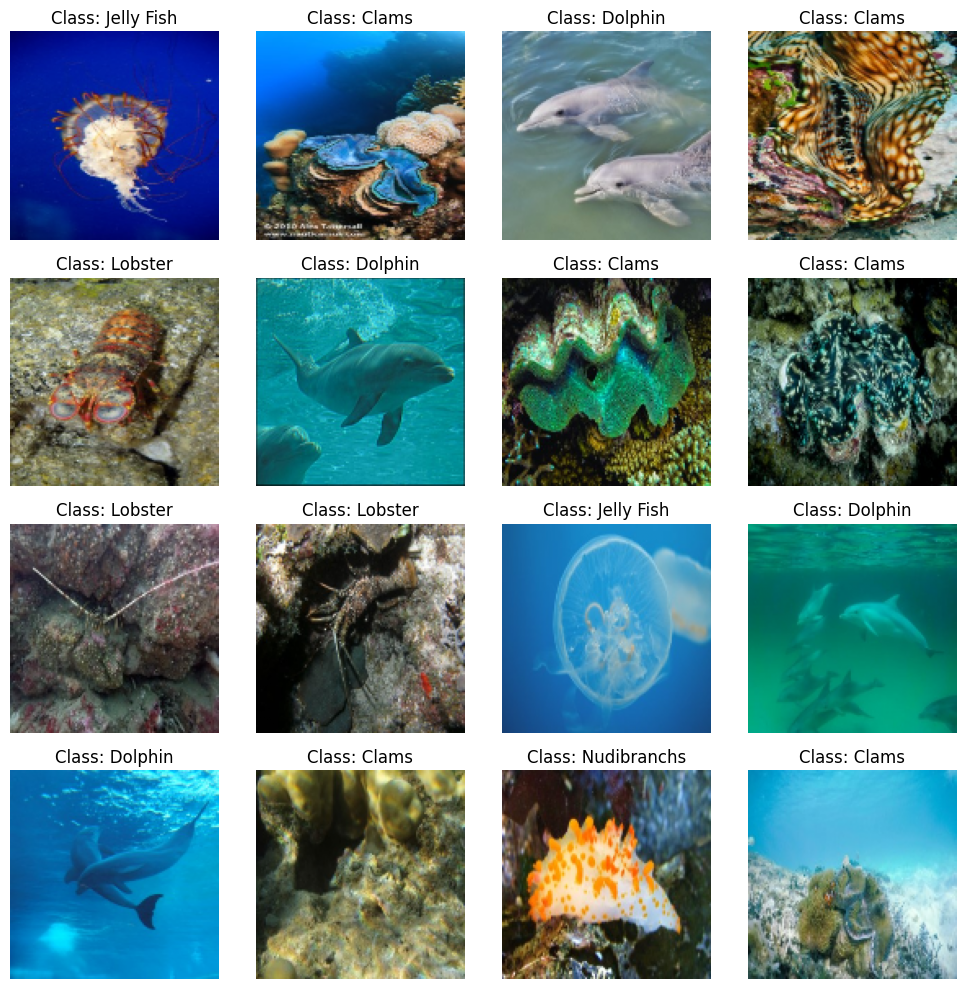

In [12]:
from random import randint

def show_images(images,labels,str_labels):
    plt.figure(figsize=(10,10))
    for i in range(16):
        ax=plt.subplot(4,4,i+1)
        idx=randint(0,len(images)-1)
        plt.imshow(images[idx])
        plt.axis('off')
        plt.title(label=f"Class: {str_labels[labels[idx]]}")
    plt.tight_layout()
    plt.show()
show_images(X,y,class_labels)

# Data Splitting

In [13]:
y=to_categorical(y)
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,shuffle=True,random_state=42,stratify=y)
print(X_train.shape,X_test.shape,y_train.shape,y_test.shape)

(2000, 128, 128, 3) (500, 128, 128, 3) (2000, 5) (500, 5)


# Algorithm: Inception V3

In [14]:
import tensorflow as tf

In [15]:
inception_model=tf.keras.applications.inception_v3.InceptionV3(include_top=False,
                                                   weights="imagenet",
                                                   input_tensor=None,
                                                   input_shape=(128,128,3),
                                                   pooling="max",
                                                   classes=1000)
inception_model.trainable = False

In [16]:
inputs = inception_model.input
dropout = tf.keras.layers.Dropout(rate=0.4)(inception_model.output)
fc1 = tf.keras.layers.Dense(512, activation='relu')(dropout)
outputs = tf.keras.layers.Dense(len(class_labels), activation='softmax')(fc1)
inception_model = tf.keras.Model(inputs=inputs, outputs=outputs)

In [17]:
inception_model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])
inception_model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 128, 128, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d (Conv2D)                (None, 63, 63, 32)   864         ['input_1[0][0]']                
                                                                                                  
 batch_normalization (BatchNorm  (None, 63, 63, 32)  96          ['conv2d[0][0]']                 
 alization)                                                                                       
                                                                                              

 batch_normalization_10 (BatchN  (None, 13, 13, 96)  288         ['conv2d_10[0][0]']              
 ormalization)                                                                                    
                                                                                                  
 batch_normalization_11 (BatchN  (None, 13, 13, 32)  96          ['conv2d_11[0][0]']              
 ormalization)                                                                                    
                                                                                                  
 activation_5 (Activation)      (None, 13, 13, 64)   0           ['batch_normalization_5[0][0]']  
                                                                                                  
 activation_7 (Activation)      (None, 13, 13, 64)   0           ['batch_normalization_7[0][0]']  
                                                                                                  
 activatio

 conv2d_20 (Conv2D)             (None, 13, 13, 48)   13824       ['mixed1[0][0]']                 
                                                                                                  
 conv2d_23 (Conv2D)             (None, 13, 13, 96)   55296       ['activation_22[0][0]']          
                                                                                                  
 batch_normalization_20 (BatchN  (None, 13, 13, 48)  144         ['conv2d_20[0][0]']              
 ormalization)                                                                                    
                                                                                                  
 batch_normalization_23 (BatchN  (None, 13, 13, 96)  288         ['conv2d_23[0][0]']              
 ormalization)                                                                                    
                                                                                                  
 activatio

                                                                                                  
 conv2d_34 (Conv2D)             (None, 6, 6, 128)    98304       ['mixed3[0][0]']                 
                                                                                                  
 batch_normalization_34 (BatchN  (None, 6, 6, 128)   384         ['conv2d_34[0][0]']              
 ormalization)                                                                                    
                                                                                                  
 activation_34 (Activation)     (None, 6, 6, 128)    0           ['batch_normalization_34[0][0]'] 
                                                                                                  
 conv2d_35 (Conv2D)             (None, 6, 6, 128)    114688      ['activation_34[0][0]']          
                                                                                                  
 batch_nor

                                                                                                  
 activation_44 (Activation)     (None, 6, 6, 160)    0           ['batch_normalization_44[0][0]'] 
                                                                                                  
 conv2d_45 (Conv2D)             (None, 6, 6, 160)    179200      ['activation_44[0][0]']          
                                                                                                  
 batch_normalization_45 (BatchN  (None, 6, 6, 160)   480         ['conv2d_45[0][0]']              
 ormalization)                                                                                    
                                                                                                  
 activation_45 (Activation)     (None, 6, 6, 160)    0           ['batch_normalization_45[0][0]'] 
                                                                                                  
 conv2d_41

 batch_normalization_55 (BatchN  (None, 6, 6, 160)   480         ['conv2d_55[0][0]']              
 ormalization)                                                                                    
                                                                                                  
 activation_55 (Activation)     (None, 6, 6, 160)    0           ['batch_normalization_55[0][0]'] 
                                                                                                  
 conv2d_51 (Conv2D)             (None, 6, 6, 160)    122880      ['mixed5[0][0]']                 
                                                                                                  
 conv2d_56 (Conv2D)             (None, 6, 6, 160)    179200      ['activation_55[0][0]']          
                                                                                                  
 batch_normalization_51 (BatchN  (None, 6, 6, 160)   480         ['conv2d_51[0][0]']              
 ormalizat

 conv2d_61 (Conv2D)             (None, 6, 6, 192)    147456      ['mixed6[0][0]']                 
                                                                                                  
 conv2d_66 (Conv2D)             (None, 6, 6, 192)    258048      ['activation_65[0][0]']          
                                                                                                  
 batch_normalization_61 (BatchN  (None, 6, 6, 192)   576         ['conv2d_61[0][0]']              
 ormalization)                                                                                    
                                                                                                  
 batch_normalization_66 (BatchN  (None, 6, 6, 192)   576         ['conv2d_66[0][0]']              
 ormalization)                                                                                    
                                                                                                  
 activatio

 ormalization)                                                                                    
                                                                                                  
 batch_normalization_74 (BatchN  (None, 6, 6, 192)   576         ['conv2d_74[0][0]']              
 ormalization)                                                                                    
                                                                                                  
 activation_70 (Activation)     (None, 6, 6, 192)    0           ['batch_normalization_70[0][0]'] 
                                                                                                  
 activation_74 (Activation)     (None, 6, 6, 192)    0           ['batch_normalization_74[0][0]'] 
                                                                                                  
 conv2d_71 (Conv2D)             (None, 2, 2, 320)    552960      ['activation_70[0][0]']          
          

                                                                                                  
 activation_82 (Activation)     (None, 2, 2, 384)    0           ['batch_normalization_82[0][0]'] 
                                                                                                  
 activation_83 (Activation)     (None, 2, 2, 384)    0           ['batch_normalization_83[0][0]'] 
                                                                                                  
 batch_normalization_84 (BatchN  (None, 2, 2, 192)   576         ['conv2d_84[0][0]']              
 ormalization)                                                                                    
                                                                                                  
 activation_76 (Activation)     (None, 2, 2, 320)    0           ['batch_normalization_76[0][0]'] 
                                                                                                  
 mixed9_0 

 ormalization)                                                                                    
                                                                                                  
 activation_85 (Activation)     (None, 2, 2, 320)    0           ['batch_normalization_85[0][0]'] 
                                                                                                  
 mixed9_1 (Concatenate)         (None, 2, 2, 768)    0           ['activation_87[0][0]',          
                                                                  'activation_88[0][0]']          
                                                                                                  
 concatenate_1 (Concatenate)    (None, 2, 2, 768)    0           ['activation_91[0][0]',          
                                                                  'activation_92[0][0]']          
                                                                                                  
 activatio

***Model training***

In [18]:
history = inception_model.fit(x=X_train, y=y_train, batch_size=32, epochs=15, validation_data=(X_test, y_test))

Epoch 1/15
63/63 [==============================] - 25s 330ms/step - loss: 1.9690 - accuracy: 0.6390 - val_loss: 0.5306 - val_accuracy: 0.7860
Epoch 2/15
63/63 [==============================] - 21s 337ms/step - loss: 0.5247 - accuracy: 0.8140 - val_loss: 0.4965 - val_accuracy: 0.8180
Epoch 3/15
63/63 [==============================] - 25s 398ms/step - loss: 0.4043 - accuracy: 0.8475 - val_loss: 0.4958 - val_accuracy: 0.8220
Epoch 4/15
63/63 [==============================] - 32s 493ms/step - loss: 0.3642 - accuracy: 0.8670 - val_loss: 0.4981 - val_accuracy: 0.8380
Epoch 5/15
63/63 [==============================] - 40s 638ms/step - loss: 0.3127 - accuracy: 0.8790 - val_loss: 0.5229 - val_accuracy: 0.8280
Epoch 6/15
63/63 [==============================] - 27s 437ms/step - loss: 0.2919 - accuracy: 0.8880 - val_loss: 0.4712 - val_accuracy: 0.8340
Epoch 7/15
63/63 [==============================] - 29s 464ms/step - loss: 0.2616 - accuracy: 0.9000 - val_loss: 0.5102 - val_accuracy: 0.8160

***Accuracy and Loss plot-graphs***

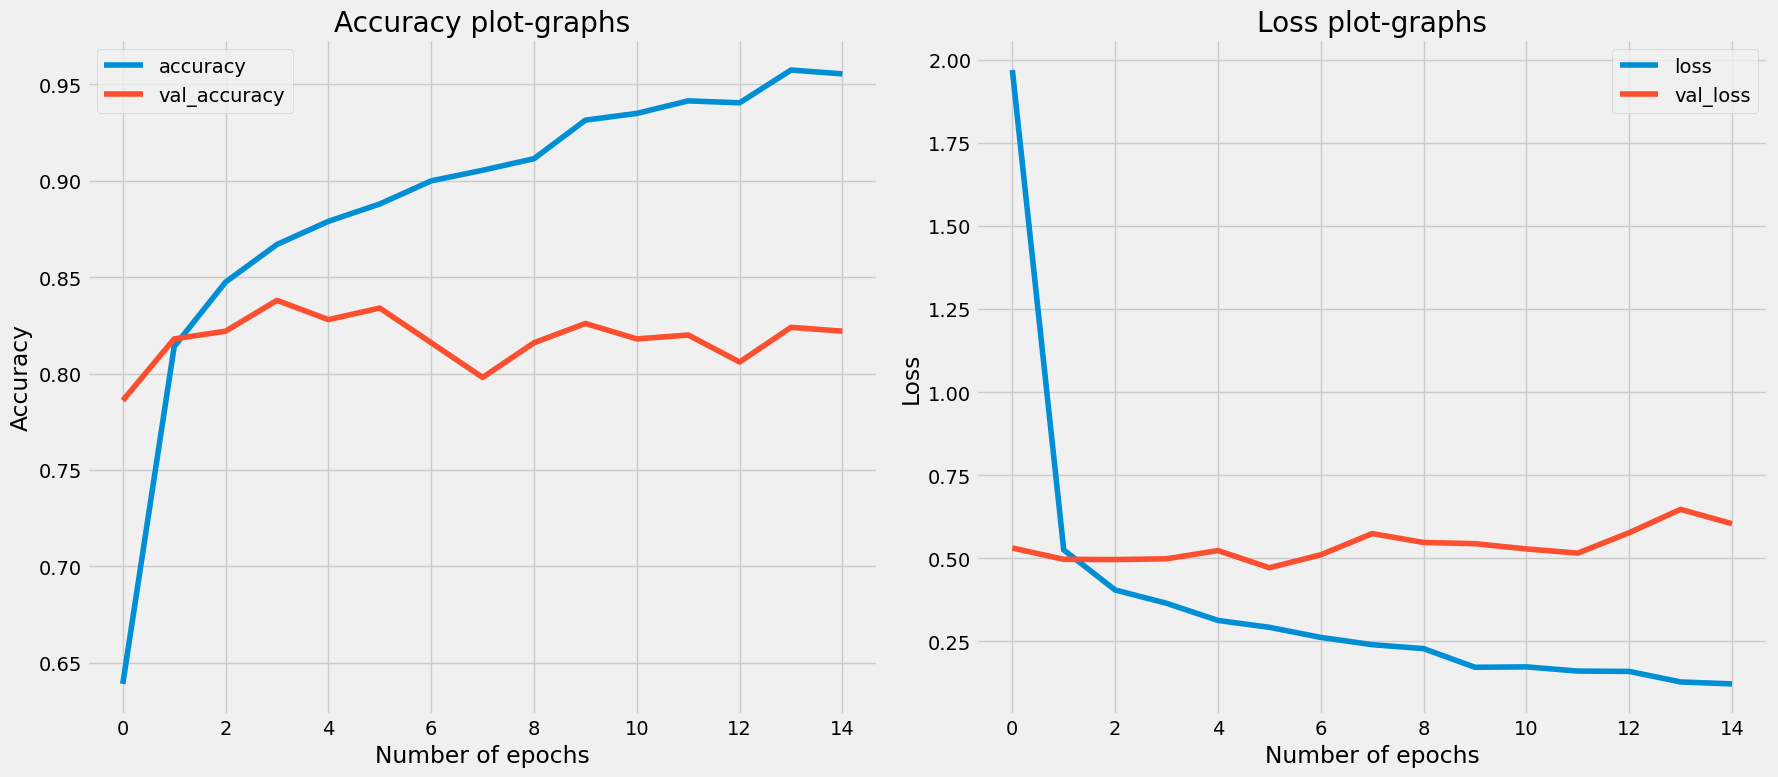

In [19]:
with plt.style.context(style='fivethirtyeight'):
    fig,axes=plt.subplots(nrows=1,ncols=2,figsize=(18,8))
    axes[0].plot(history.history["accuracy"],label="accuracy")
    axes[0].plot(history.history["val_accuracy"],label="val_accuracy")
    axes[0].set_title(label='Accuracy plot-graphs')
    axes[0].set_xlabel(xlabel='Number of epochs')
    axes[0].set_ylabel(ylabel='Accuracy')
    axes[0].legend()
    axes[1].plot(history.history["loss"],label="loss")
    axes[1].plot(history.history["val_loss"],label="val_loss")
    axes[1].set_title(label='Loss plot-graphs')
    axes[1].set_xlabel(xlabel='Number of epochs')
    axes[1].set_ylabel(ylabel='Loss')
    axes[1].legend()
    fig.tight_layout()
    plt.show()

In [20]:
inception_model_prediction=inception_model.predict(X_test,batch_size=32,verbose=1)

16/16 [==============================] - 8s 345ms/step


In [21]:
print(inception_model_prediction)

[[1.6255984e-03 2.8718354e-08 2.5506233e-07 9.7378141e-01 2.4592690e-02]
 [5.2570699e-09 1.4364504e-11 1.0000000e+00 1.5117815e-10 9.8088062e-09]
 [5.8590369e-05 9.9990797e-01 3.9673591e-06 4.4894246e-06 2.4905679e-05]
 ...
 [3.3600352e-04 2.1334094e-11 1.0612646e-09 2.5377299e-03 9.9712628e-01]
 [2.2285248e-04 9.9936682e-01 3.1226546e-07 1.3159473e-04 2.7846283e-04]
 [4.7651130e-15 2.9095265e-13 1.0000000e+00 1.5023818e-10 1.8542961e-13]]


In [22]:
pred = np.argmax(inception_model_prediction,axis=1)
actual = np.argmax(y_test,axis=1)

In [23]:
print(pred.tolist())

[3, 2, 1, 2, 2, 0, 2, 3, 0, 0, 1, 2, 3, 4, 2, 4, 3, 4, 3, 0, 2, 2, 0, 2, 1, 0, 3, 1, 4, 0, 2, 3, 3, 0, 1, 2, 0, 4, 2, 3, 1, 1, 1, 4, 4, 1, 3, 1, 2, 4, 4, 1, 1, 1, 3, 2, 0, 4, 3, 1, 4, 2, 3, 3, 4, 4, 2, 3, 2, 2, 1, 3, 1, 4, 2, 4, 1, 1, 0, 3, 4, 3, 3, 2, 1, 2, 3, 4, 1, 3, 4, 4, 0, 0, 2, 2, 2, 4, 0, 3, 2, 4, 3, 2, 0, 1, 3, 0, 2, 0, 0, 3, 3, 1, 0, 3, 0, 4, 4, 3, 1, 2, 0, 4, 3, 3, 3, 4, 4, 3, 2, 4, 3, 1, 4, 3, 1, 4, 2, 3, 0, 1, 1, 0, 1, 4, 4, 0, 3, 1, 2, 0, 0, 2, 1, 0, 2, 0, 3, 3, 2, 2, 4, 0, 0, 4, 3, 1, 3, 0, 4, 1, 4, 2, 0, 0, 3, 1, 3, 2, 1, 0, 0, 1, 0, 3, 4, 3, 4, 2, 2, 1, 1, 0, 0, 2, 0, 2, 1, 4, 4, 4, 1, 4, 3, 2, 1, 3, 3, 2, 3, 4, 4, 0, 2, 1, 0, 0, 3, 1, 2, 3, 4, 4, 1, 2, 0, 4, 3, 2, 2, 4, 1, 1, 2, 1, 2, 2, 1, 3, 0, 0, 1, 3, 0, 2, 0, 0, 2, 4, 3, 0, 1, 0, 2, 0, 1, 4, 0, 1, 4, 3, 1, 3, 4, 2, 0, 0, 2, 4, 3, 3, 4, 1, 4, 3, 4, 4, 2, 3, 0, 2, 0, 4, 3, 2, 3, 1, 3, 2, 3, 4, 3, 0, 2, 0, 1, 3, 2, 0, 3, 1, 3, 4, 3, 1, 3, 1, 3, 4, 0, 2, 2, 4, 3, 0, 4, 2, 3, 1, 3, 1, 0, 4, 1, 1, 1, 2, 4, 3, 2, 3, 0, 

In [24]:
print(actual.tolist())

[0, 2, 1, 2, 2, 0, 2, 3, 0, 0, 1, 2, 3, 4, 2, 0, 3, 4, 3, 0, 2, 2, 0, 2, 1, 0, 3, 1, 4, 0, 2, 0, 3, 0, 1, 2, 0, 0, 2, 3, 2, 1, 1, 4, 4, 1, 3, 2, 2, 3, 4, 1, 1, 1, 2, 2, 4, 0, 3, 1, 4, 2, 3, 4, 4, 4, 2, 4, 2, 2, 1, 0, 1, 4, 2, 0, 1, 1, 4, 3, 1, 3, 4, 2, 1, 2, 0, 4, 1, 0, 4, 0, 0, 0, 2, 2, 2, 0, 0, 2, 2, 4, 4, 2, 0, 1, 3, 0, 2, 0, 0, 0, 3, 1, 0, 3, 0, 0, 4, 4, 1, 2, 0, 4, 3, 3, 3, 4, 4, 4, 2, 4, 3, 1, 4, 3, 1, 4, 2, 3, 0, 1, 1, 0, 1, 4, 4, 0, 3, 1, 2, 0, 4, 2, 1, 3, 2, 0, 4, 3, 2, 2, 4, 0, 0, 4, 3, 1, 0, 0, 3, 1, 0, 2, 3, 0, 3, 1, 3, 2, 1, 0, 0, 1, 0, 3, 4, 4, 4, 2, 2, 1, 1, 0, 0, 2, 0, 2, 1, 4, 4, 4, 1, 4, 3, 2, 1, 3, 0, 0, 4, 4, 0, 3, 2, 1, 3, 0, 3, 1, 2, 0, 4, 0, 1, 2, 0, 4, 3, 2, 2, 4, 1, 1, 2, 1, 2, 2, 1, 3, 0, 0, 1, 3, 0, 2, 0, 0, 2, 3, 3, 0, 1, 0, 2, 3, 1, 4, 0, 1, 4, 3, 1, 4, 4, 2, 0, 0, 2, 0, 0, 2, 4, 1, 4, 3, 4, 3, 2, 0, 1, 2, 0, 4, 3, 2, 3, 1, 3, 2, 4, 4, 3, 0, 2, 0, 1, 3, 2, 0, 4, 1, 3, 4, 3, 1, 3, 1, 3, 4, 0, 2, 2, 4, 3, 0, 4, 2, 3, 1, 3, 1, 0, 4, 1, 1, 1, 2, 4, 4, 2, 3, 0, 

### Result Analysis

***Accuracy Score***

In [25]:
accuracy=accuracy_score(y_true=actual,y_pred=pred)
print(f"Validation accuracy of InceptionV3 model is {accuracy*100.0:.2f}%")

Validation accuracy of InceptionV3 model is 82.20%


***Classification Report***

In [26]:
print(classification_report(y_true=actual,y_pred=pred,target_names=class_labels))

              precision    recall  f1-score   support

       Clams       0.76      0.68      0.72       100
     Dolphin       0.98      0.98      0.98       100
  Jelly Fish       0.97      0.92      0.94       100
     Lobster       0.70      0.81      0.75       100
 Nudibranchs       0.73      0.72      0.72       100

    accuracy                           0.82       500
   macro avg       0.83      0.82      0.82       500
weighted avg       0.83      0.82      0.82       500



***Confusion Matrix***

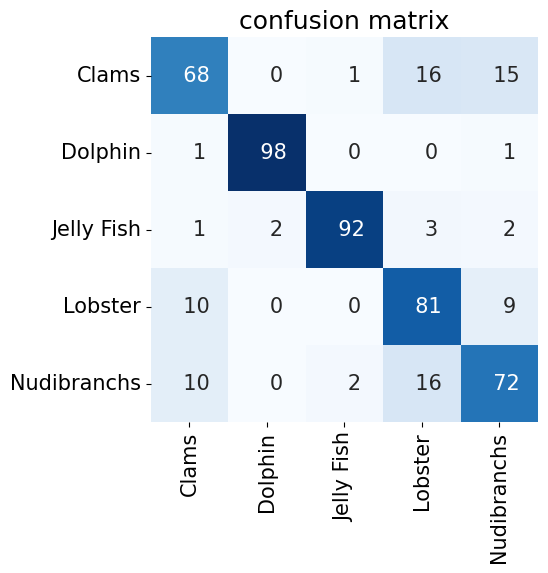

In [27]:
plt.figure(figsize=(5,5))
plt.rcParams['font.size']=15
ax=sns.heatmap(data=confusion_matrix(y_true=actual,y_pred=pred),
               annot=True,
               fmt='4d',
               cbar=False,
               xticklabels=class_labels,
               yticklabels=class_labels,
               cmap=plt.cm.Blues)
plt.title(label='confusion matrix')
plt.show()

***model saving***

In [28]:
inception_model.save("models/InceptionV3_model.h5")

---